# ДЗ 11 — Случайный лес (Random Forest)

**Датасет:** тот же, что в ДЗ №4 — *Life Expectancy Data* (WHO / Kaggle): регрессия **`Life expectancy`** по экономическим и медицинским признакам.

**Файл данных:** `hw04_LRR/life_expectancy_data.csv` (относительно корня репозитория).

Ниже: краткий **EDA с графиками** (как в типовом отчёте), предобработка, сравнение **линейной регрессии**, **одного дерева** и **случайного леса** с одинаковой `max_depth`, затем **сравнение моделей и остатков** на графиках. Текстовые ответы на вопросы задания — в markdown после соответствующих разделов.


In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="viridis")

RANDOM_STATE = 42
MAX_DEPTH = 15
N_TREES = 200

def find_data_csv():
    cwd = Path.cwd()
    names = ("life_expectancy_data.csv", "Life_Expectancy_Data.csv")
    for base in (cwd, cwd.parent):
        for fname in names:
            p = base / "hw04_LRR" / fname
            if p.exists():
                return p
    raise FileNotFoundError(
        "Нет CSV в hw04_LRR/ (ожидаются life_expectancy_data.csv или Life_Expectancy_Data.csv)."
    )

CSV_PATH = find_data_csv()
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()

TARGET = "Life expectancy"
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
_before = len(df)
df = df.dropna(subset=[TARGET])
if len(df) < _before:
    print(f"Удалено строк без корректного '{TARGET}': {_before - len(df)}")

X = df.drop(columns=[TARGET, "Country"]).reset_index(drop=True)
y = df[TARGET].astype(float).reset_index(drop=True)

cat_cols = ["Status"]
num_cols = [c for c in X.columns if c not in cat_cols]

assert not y.isna().any(), "В целевой переменной остались NaN — проверьте CSV."

print("Файл:", CSV_PATH.resolve())
print("Размеры X, y:", X.shape, y.shape)
print("Пропуски в X (по столбцам):", X.isna().sum().sum())



Удалено строк без корректного 'Life expectancy': 10
Файл: /Users/Chamomile/Desktop/ml-famcs-homeworks/hw04_LRR/life_expectancy_data.csv
Размеры X, y: (2928, 20) (2928,)
Пропуски в X (по столбцам): 2513


## EDA и визуализация данных

Коротко смотрим распределение цели, связь с несколькими признаками и корреляции числовых колонок — это не обязательное требование формулировки ДЗ, но делает работу нагляднее (аналогично примеру с другим датасетом).


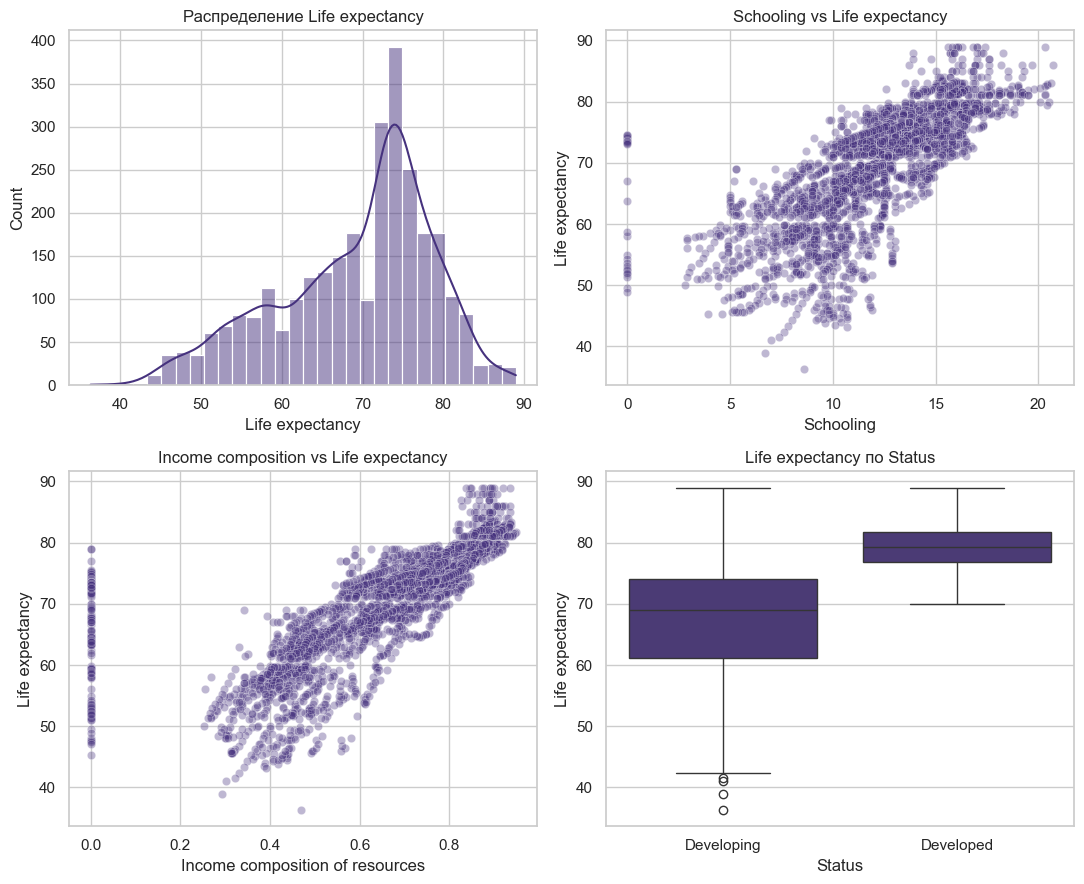

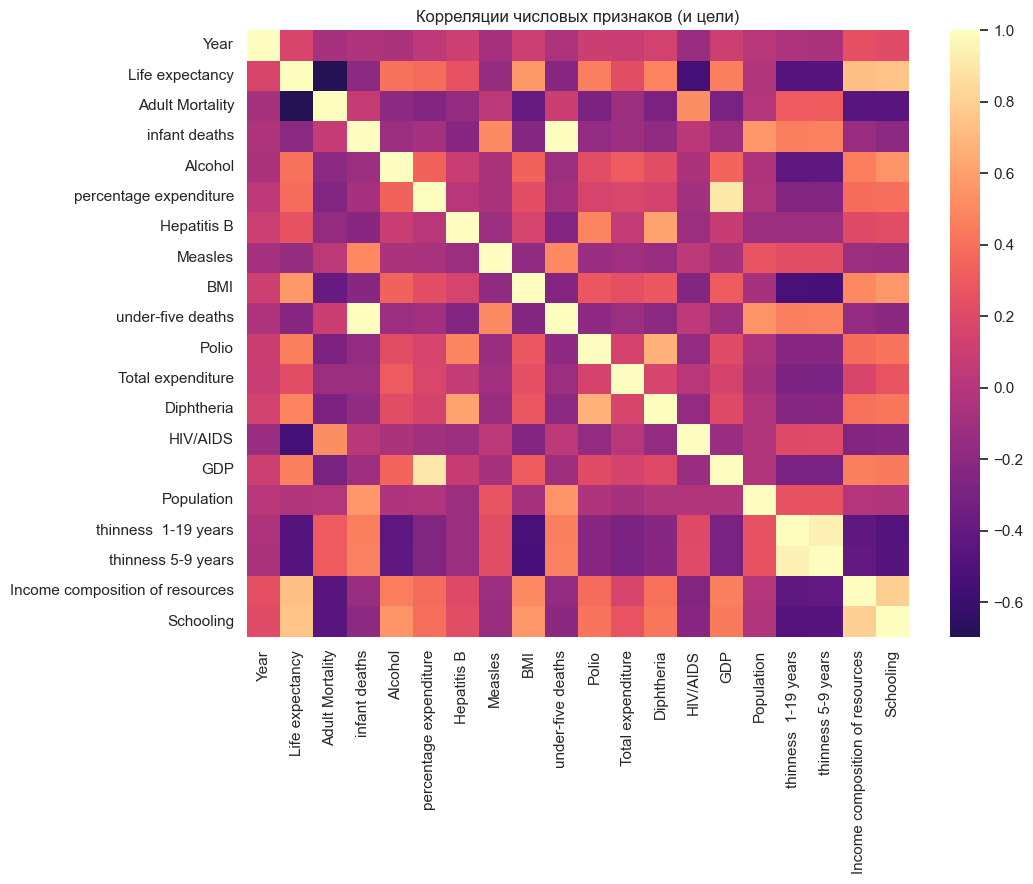

In [2]:

eda_df = df[[TARGET, "Status", "Schooling", "Income composition of resources", "GDP", "Adult Mortality"]].copy()

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
sns.histplot(y, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Распределение Life expectancy")

sns.scatterplot(x="Schooling", y=TARGET, data=eda_df, alpha=0.35, ax=axes[0, 1])
axes[0, 1].set_title("Schooling vs Life expectancy")

sns.scatterplot(x="Income composition of resources", y=TARGET, data=eda_df, alpha=0.35, ax=axes[1, 0])
axes[1, 0].set_title("Income composition vs Life expectancy")

sns.boxplot(x="Status", y=TARGET, data=eda_df, ax=axes[1, 1])
axes[1, 1].set_title("Life expectancy по Status")
plt.tight_layout()
plt.show()


num_for_corr = df.drop(columns=["Country"]).select_dtypes(include=[np.number])
corr = num_for_corr.corr(numeric_only=True)
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="magma", center=0, annot=False)
plt.title("Корреляции числовых признаков (и цели)")
plt.tight_layout()
plt.show()



In [3]:


preprocess_lin = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            num_cols,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            cat_cols,
        ),
    ]
)


preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            cat_cols,
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Страховка: отбрасываем нечисловые/NaN в y (если ядро в старом состоянии без очистки в ячейке 1)
def _drop_bad_y(Xa, ya):
    m = np.isfinite(ya.to_numpy(dtype=float))
    return Xa.loc[m].reset_index(drop=True), ya.loc[m].reset_index(drop=True)

X_train, y_train = _drop_bad_y(X_train, y_train)
X_test, y_test = _drop_bad_y(X_test, y_test)

X_train.shape, X_test.shape, y_train.isna().sum(), y_test.isna().sum()



((2342, 20), (586, 20), np.int64(0), np.int64(0))

## 1. Разделение выборки — ответы текстом

**Сделали ли предобработку для случайного леса? Отличалась ли она от линейной модели?**

Да. Для **деревьев** мы по-прежнему обрабатываем пропуски (медиана / мода) и кодируем `Status` через **One-Hot**, чтобы модель могла использовать категорию. **Отличие:** для числовых признаков **не применяли `StandardScaler`**. Деревья строят разбиения по порогам; масштаб чисел не меняет порядок значений и не меняет структуру дерева (в отличие от расстояний в SVM или от штрафов в Ridge/Lasso). Для **линейной регрессии** масштабирование важно для интерпретации коэффициентов и для сопоставимости признаков при регуляризации — как в ДЗ 4.

**Как разделили выборку?**

**Train / test = 80% / 20%**, `random_state=42`, **без стратификации** (целевая переменная непрерывная; стратификация обычно для классификации).

**На сколько частей делить при кросс-валидации?**

Чаще всего **K = 5 или K = 10** фолдов: компромисс между дисперсией оценки и стоимостью обучения. В sklearn это `cv=5` или `cv=10`.

**Можно ли не использовать кросс-валидацию?**

Да. Тогда фиксируют **одно отложенное разбиение** (как здесь: train для обучения, **test только для финальной оценки**) или схему **train / validation / test** (подбор гиперпараметров на val, итог — на test). Без CV важно не подгонять модель по test и не повторять подбор много раз «пока не вырастет метрика» — иначе test перестаёт быть честной оценкой обобщения.


In [4]:
def metrics_report(name, model, X_tr, y_tr, X_te, y_te):
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)
    rows = []
    for split, y_true, pred in [
        ("Train", y_tr, pred_tr),
        ("Test", y_te, pred_te),
    ]:
        mse = mean_squared_error(y_true, pred)
        rows.append(
            {
                "model": name,
                "split": split,
                "RMSE": float(np.sqrt(mse)),
                "MAE": float(mean_absolute_error(y_true, pred)),
                "R2": float(r2_score(y_true, pred)),
            }
        )
        print(
            f"{name} [{split}]  RMSE={np.sqrt(mse):.4f}  MAE={mean_absolute_error(y_true, pred):.4f}  R²={r2_score(y_true, pred):.4f}"
        )
    return pd.DataFrame(rows)


pipe_lin = Pipeline([("prep", preprocess_lin), ("model", LinearRegression())])

t0 = time.perf_counter()
pipe_lin.fit(X_train, y_train)
time_lin = time.perf_counter() - t0
print(f"Время обучения LinearRegression: {time_lin:.4f} с\n")

metrics_report("LinearRegression", pipe_lin, X_train, y_train, X_test, y_test)


Время обучения LinearRegression: 0.0210 с

LinearRegression [Train]  RMSE=4.0601  MAE=3.0312  R²=0.8202
LinearRegression [Test]  RMSE=3.9515  MAE=2.9273  R²=0.8195


,model,split,RMSE,MAE,R2
0,LinearRegression,Train,4.060066,3.031196,0.820216
1,LinearRegression,Test,3.951483,2.927327,0.819488


In [5]:
pipe_tree = Pipeline(
    [
        ("prep", preprocess_tree),
        ("model", DecisionTreeRegressor(max_depth=MAX_DEPTH, random_state=RANDOM_STATE)),
    ]
)

pipe_rf = Pipeline(
    [
        ("prep", preprocess_tree),
        (
            "model",
            RandomForestRegressor(
                max_depth=MAX_DEPTH,
                n_estimators=N_TREES,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

print(f"Одно дерево: max_depth={MAX_DEPTH}")
t0 = time.perf_counter()
pipe_tree.fit(X_train, y_train)
time_tree = time.perf_counter() - t0
print(f"Время обучения DecisionTreeRegressor: {time_tree:.4f} с\n")
metrics_report("DecisionTree", pipe_tree, X_train, y_train, X_test, y_test)

print(f"\nСлучайный лес: max_depth={MAX_DEPTH}, n_estimators={N_TREES}")
t0 = time.perf_counter()
pipe_rf.fit(X_train, y_train)
time_rf = time.perf_counter() - t0
print(f"Время обучения RandomForestRegressor: {time_rf:.4f} с\n")
metrics_report("RandomForest", pipe_rf, X_train, y_train, X_test, y_test)

print("\n--- Сводка по времени только fit ---")
print(f"LinearRegression:   {time_lin:.4f} с")
print(f"DecisionTree:       {time_tree:.4f} с")
print(f"RandomForest:       {time_rf:.4f} с")


Одно дерево: max_depth=15
Время обучения DecisionTreeRegressor: 0.0336 с

DecisionTree [Train]  RMSE=0.4491  MAE=0.1243  R²=0.9978
DecisionTree [Test]  RMSE=2.6068  MAE=1.5483  R²=0.9214

Случайный лес: max_depth=15, n_estimators=200
Время обучения RandomForestRegressor: 0.5375 с

RandomForest [Train]  RMSE=0.7060  MAE=0.4500  R²=0.9946
RandomForest [Test]  RMSE=1.6925  MAE=1.0611  R²=0.9669

--- Сводка по времени только fit ---
LinearRegression:   0.0210 с
DecisionTree:       0.0336 с
RandomForest:       0.5375 с


## 2. Обучение моделей — ответы

**Сравнение скорости.** Обычно **быстрее всего одно дерево** (один проход построения). **Линейная регрессия** после предобработки тоже очень быстрая (аналитическое решение в пространстве признаков фиксированной размерности). **Случайный лес** с тем же `max_depth`, но с большим числом деревьев (`n_estimators`) обучает **много** деревьев на бутстрап-подвыборках — это **медленнее** одного дерева; ускоряют `n_jobs=-1` и меньшее число деревьев.

**Можно ли добиться одинаковой или близкой скорости?** Полного совпадения нет: лес по определению делает **вклад деревьев × стоимость одного дерева**. Можно **уменьшить `n_estimators`**, упростить данные или использовать меньшую глубину — тогда время приблизится к одному дереву, но **качество** леса может упасть. У одинаковой глубины **одно дерево** и **один компонент леса** сопоставимы по сложности, но лес — это **сумма** таких обучений.

**Сравнение качества.** На тесте **одно дерево** сильнее склонно к **переобучению** (высокий train, хуже test). **Случайный лес** усредняя предсказания, обычно **лучше обобщает** и даёт **ниже ошибку на test**, чем один глубокий `DecisionTreeRegressor`. Конкретные числа — по выводу ячеек выше.


In [6]:

pipe_rf_cv = Pipeline(
    [
        ("prep", preprocess_tree),
        (
            "model",
            RandomForestRegressor(
                max_depth=MAX_DEPTH,
                n_estimators=N_TREES,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)
cv_scores = cross_val_score(
    pipe_rf_cv, X_train, y_train, cv=5, scoring="r2", n_jobs=-1
)
print("5-fold CV R² на train-части (RandomForest):", cv_scores)
print("mean ± std:", cv_scores.mean(), cv_scores.std())


5-fold CV R² на train-части (RandomForest): [0.95795656 0.95762134 0.9498177  0.96334664 0.96287721]
mean ± std: 0.9583238911530243 0.004877388770520728


,model,RMSE_test,MAE_test,R2_test
2,RandomForest,1.692472,1.061055,0.966885
1,DecisionTree,2.606781,1.548330,0.921441
0,LinearRegression,3.951483,2.927327,0.819488


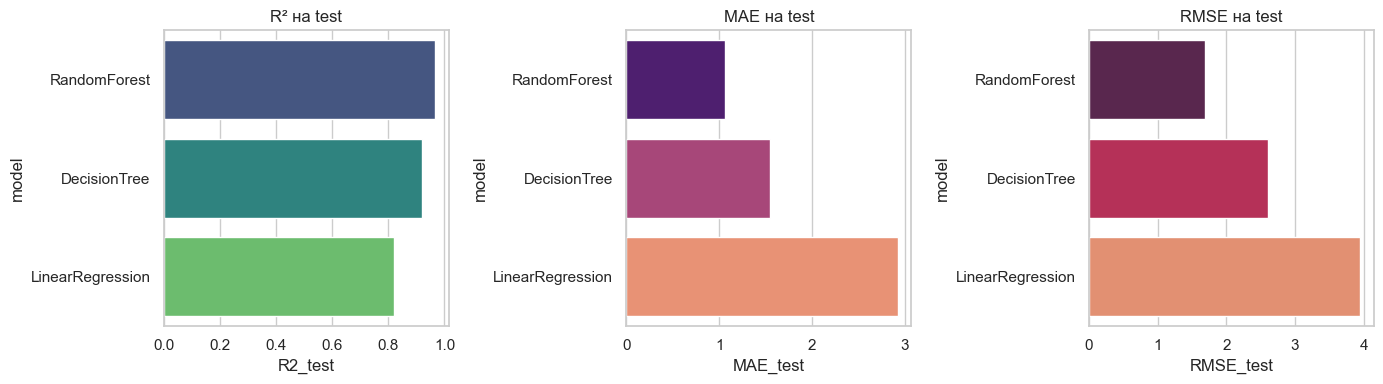

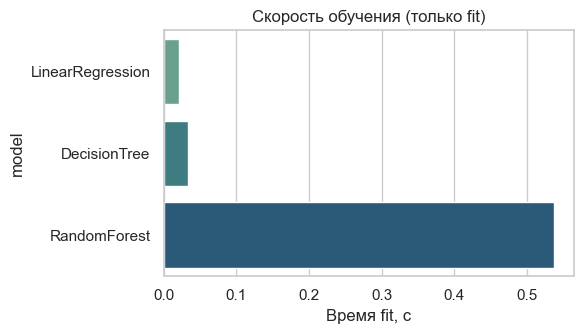

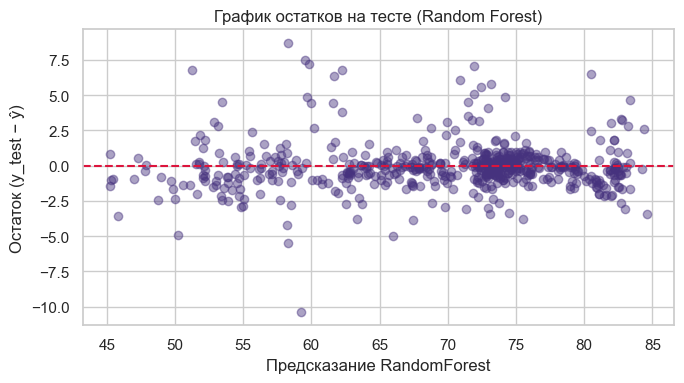

In [7]:

rows = []
for name, model in [
    ("LinearRegression", pipe_lin),
    ("DecisionTree", pipe_tree),
    ("RandomForest", pipe_rf),
]:
    pred = model.predict(X_test)
    rows.append(
        {
            "model": name,
            "RMSE_test": np.sqrt(mean_squared_error(y_test, pred)),
            "MAE_test": mean_absolute_error(y_test, pred),
            "R2_test": r2_score(y_test, pred),
        }
    )

summary = pd.DataFrame(rows).sort_values("RMSE_test")
display(summary)


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
order = summary.sort_values("R2_test", ascending=False)["model"]
sns.barplot(data=summary, x="R2_test", y="model", order=order, ax=axes[0], palette="viridis")
axes[0].set_title("R² на test")

sns.barplot(data=summary, x="MAE_test", y="model", order=summary.sort_values("MAE_test")["model"], ax=axes[1], palette="magma")
axes[1].set_title("MAE на test")

sns.barplot(data=summary, x="RMSE_test", y="model", order=summary.sort_values("RMSE_test")["model"], ax=axes[2], palette="rocket")
axes[2].set_title("RMSE на test")
plt.tight_layout()
plt.show()


timing = pd.DataFrame(
    {
        "model": ["LinearRegression", "DecisionTree", "RandomForest"],
        "time_s": [time_lin, time_tree, time_rf],
    }
)
plt.figure(figsize=(6, 3.5))
sns.barplot(data=timing, x="time_s", y="model", palette="crest")
plt.xlabel("Время fit, с")
plt.title("Скорость обучения (только fit)")
plt.tight_layout()
plt.show()


pred_rf = pipe_rf.predict(X_test)
residuals = y_test - pred_rf
plt.figure(figsize=(7, 4))
plt.scatter(pred_rf, residuals, alpha=0.45)
plt.axhline(0, color="crimson", linestyle="--")
plt.xlabel("Предсказание RandomForest")
plt.ylabel("Остаток (y_test − ŷ)")
plt.title("График остатков на тесте (Random Forest)")
plt.tight_layout()
plt.show()



## 3. Оценка качества и сравнение с линейной регрессией — ответы

1. **Какие метрики использовали?**  
   **RMSE** (корень из MSE) — в тех же единицах, что и целевая (годы жизни); сильнее штрафует большие ошибки. **MAE** — средняя абсолютная ошибка, проще интерпретировать и устойчивее к выбросам. **R²** — доля объяснённой дисперсии относительно предсказания константой средним; удобно сравнивать модели на одной задаче. В ДЗ 4 использовались те же метрики — здесь сопоставление прямое.

2. **На какой части считали метрики?**  
   Итоговые цифры в таблице — на **отложенной тестовой выборке (20%)**, которая **не участвовала** в обучении. Дополнительно в ячейках выводятся **train** и **test** для контроля переобучения. **CV (5 фолдов)** показан как оценка стабильности на train без peek на test.

3. **Какая модель лучше?**  
   По таблице на test однозначно *Random Forest*: у него минимальные RMSE и MAE и максимальный R² (~0,97). Decision Tree — второй по качеству. *Linear Regression* — слабее всех по этим трём метрикам, но всё ещё с R² ≈ 0,82, то есть не «плохая» в абсолютном смысле, просто хуже двух деревянных моделей на этих данных

4. **Насколько хорошие результаты?**  
   Random Forest: R² ≈ 0,97 — для регрессии по табличным данным это очень сильный уровень: модель объясняет почти весь разброс цели на тесте. RMSE ≈ 1,7 года и MAE ≈ 1,1 года — типичная ошибка прогноза ожидаемой продолжительности жизни порядка 1–2 лет, на фоне диапазона ~50–85 лет это очень хорошо 
Линейная регрессия: R² ≈ 0,82, RMSE ≈ 4 года — это хороший результат в духе задания в 4 дз, просто лес заметно точнее на этой выборке.
